In [1]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(scutilsR)
library(tidyverse)
library(celda)
library(sceasy)
library(Nebulosa)
library(glue)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
✔ readr     2.1.5     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGeneri

In [ ]:
## QC
seu = qs::qread("/home/data/tanglei/project/prostate_altas/output/02/Integration_GSE.qs")

In [2]:
##加载函数
FindDEGs = function(seu, nn.idents, assay=NULL) {
  if (is.null(assay)) {
    assay = DefaultAssay(seu)
  }
  cells.use = CellsByIdentities(seu, idents = nn.idents)
  cells.1 = cells.use[[nn.idents[1]]]
  cells.2 = cells.use[[nn.idents[2]]]
  if(length(cells.1) < 3 || length(cells.2) < 3) {
    return(NULL)
  }
  subsample.cells = function(cells, size=1000) {
    if (length(cells) > size) {
      cells = sample(cells, size = size)
    }
    return(cells)
  }
  cells.1 = subsample.cells(cells.1)
  cells.2 = subsample.cells(cells.2)
  markers = FindMarkers(seu[[assay]], cells.1 = cells.1, cells.2 = cells.2, test.use = "wilcox")
  if (nrow(markers) == 0) {
    return(NULL)
  }
  markers = markers %>% 
    mutate(pct.fg = abs(pct.1 - pct.2) / ifelse(pct.1 > pct.2, pct.1, pct.2)) %>% 
    filter(abs(avg_log2FC) > 1, p_val_adj < 1e-5, pct.fg > 0.5, pct.1 > 0.3 | pct.2 > 0.3)
  return(markers)
}

FindUnevenGenes <- function(seu, group.by = "seurat_clusters", gini.cutoff = 0.3, min.mean = 0.1) {
  # 计算每个 cluster 的平均表达矩阵
  avg.expr <- AverageExpression(seu, group.by = group.by, assays = "RNA")$RNA
  # 每个基因的平均表达量
  mean.expr <- rowMeans(avg.expr)
  # 计算 Gini 系数：表达越集中 → Gini 越高；表达越平均 → Gini 越低
  gini.scores <- apply(avg.expr, 1, ineq::Gini)
  # 输出结果表
  result <- data.frame(
    gene = rownames(avg.expr),
    gini = gini.scores,
    mean_expr = mean.expr
  )
  return(result)
}

质控原则：在过度聚类的前提下，如果某个小群只有单一的细胞类型标志物，那么认为是高质量；如果没有标志物，那么认为是低质量；如果有多个标志物，那么可能是低质量也可能是中间态细胞，为了进一步增加中间态细胞的识别，这里辅以质控指标，如果质控指标较差则认为是低质量，反之。但是如何认定质控指标较差？如果只用第一步计算的高质量细胞占比，不无法确定一个满意的阈值，所以这里引入了类不平衡基因，即通过Gini系数选择更有意义的“差异基因”防止背景噪音干扰，并将其进行表达与否的二值化以及可视化，更直观的分辨对于一些有多个标志物的cluster到底是中间态还是双细胞或者环境污染。我们针对CIG的二值化矩阵进行OT距离计算以及聚类，这样我们可以根据质控指标和CIG同时异常定位到最明显的低质量群，在根据聚类的结果锁定同类型但是指标看上去模棱两可的

In [7]:
library(future)
plan(sequential)   # 关键：禁用 future 并行导出
# options(future.globals.maxSize = Inf) 不建议，风险大且可能非常慢/占内存

In [8]:
## iterative cluster
## init cluster
init.k = 15
init.res = 1
seu = FindNeighbors(seu, reduction = "rpca", dims = 1:50, k.param = init.k)
seu = FindClusters(seu, graph.name = "RNA_snn", resolution = init.res)

Computing nearest neighbor graph



In [4]:
## 2nd cluster
min.cells = 50
graph.name = "RNA_snn"
subcluster.name = "iter_clusters.r1"
iter.res = 0.4

Idents(seu) = "RNA_snn_res.1"
clusters = unique(seu$RNA_snn_res.1)
clu.cells = table(seu$RNA_snn_res.1)
new.idents = as.character(Idents(seu))
cells.idents = CellsByIdentities(seu)

In [5]:
for (cl in clusters) {
  if (clu.cells[cl] <= min.cells) {
    next
  }
  cells.use = cells.idents[[cl]]
  seu = FindSubCluster(seu, cluster = cl, graph.name = graph.name, subcluster.name = subcluster.name, resolution = iter.res)
  new.idents[cells.use] = seu$iter_clusters.r1[cells.use]
}
seu[[subcluster.name]] = factor(new.idents)
Idents(seu) = subcluster.name
na.idx = is.na(seu[[subcluster.name, drop = TRUE]])
if (any(na.idx)) {
  cur.vals = as.character(seu[[subcluster.name, drop = TRUE]])
  cur.vals[na.idx] = as.character(seu$RNA_snn_res.1)[na.idx]
  seu[[subcluster.name]] = factor(cur.vals)
  Idents(seu) = subcluster.name
}

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 55194
Number of edges: 2461793

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7999
Number of communities: 7
Elapsed time: 37 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 29311
Number of edges: 1200962

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8343
Number of communities: 7
Elapsed time: 12 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 938
Number of edges: 25559

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8591
Number of communities: 4
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 14523
Number of edges: 598051

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8427
Number of communities: 6
Elapsed time: 3 seconds
Modularity Opti

4 singletons identified. 2 final clusters.



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 148
Number of edges: 4738

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.6410
Number of communities: 2
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2210
Number of edges: 80519

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8178
Number of communities: 6
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1753
Number of edges: 69637

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8197
Number of communities: 6
Elapsed time: 0 seconds


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



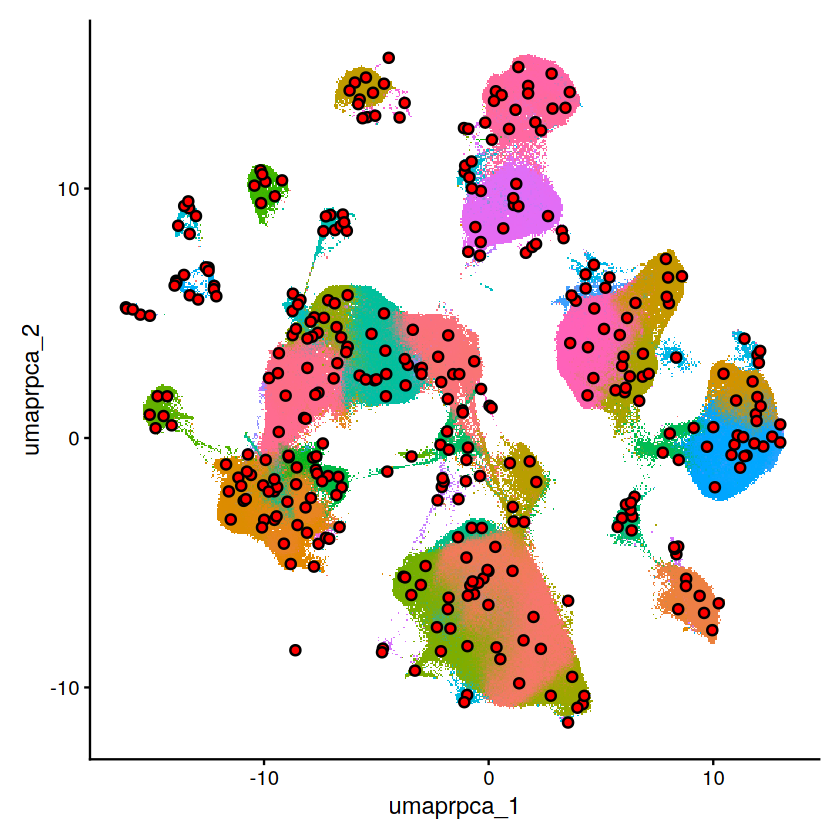

In [6]:
## calculate the center of the cluster
emb = Embeddings(seu, reduction = "umap.rpca")
data.use = FetchData(seu, vars = subcluster.name)
data.use = cbind(data.use, emb)
clu.center = data.use %>% group_by(iter_clusters.r1) %>% reframe(x=median(umaprpca_1), y=median(umaprpca_2))

DimPlot(seu, reduction = "umap.rpca", label = F, repel = F, label.size = 3) + 
  geom_point(inherit.aes = F, data = clu.center, mapping = aes(x,y), shape=21, size=2, fill="red", color="black", stroke = .8) + 
  NoLegend()

In [7]:
##  计算CIG
seu$major.celltype = "non-immune"
seu$major.celltype[seu$celltype %in% c("Mast Cells","B Cells","Dendritic Cells", "Macrophages", "NK Cells", "T Cells")] = "immune"
Idents(seu) = "major.celltype"
seu = JoinLayers(seu)
degs = FindDEGs(seu, nn.idents = c("immune", "non-immune"))
uneven.genes = FindUnevenGenes(seu, group.by = "iter_clusters.r1")
genes.show = rownames(degs)

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
Names of identity class contain underscores ('_'), replacing with dashes ('-')
This message is displayed once every 8 hours.
First group.by variable `iter_clusters.r1` starts with a number, appending `g` to ensure valid variable names
This message is displayed once every 8 hours.


Finding variable features for layer counts

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 2715 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“ggrepel: 663 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 656 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


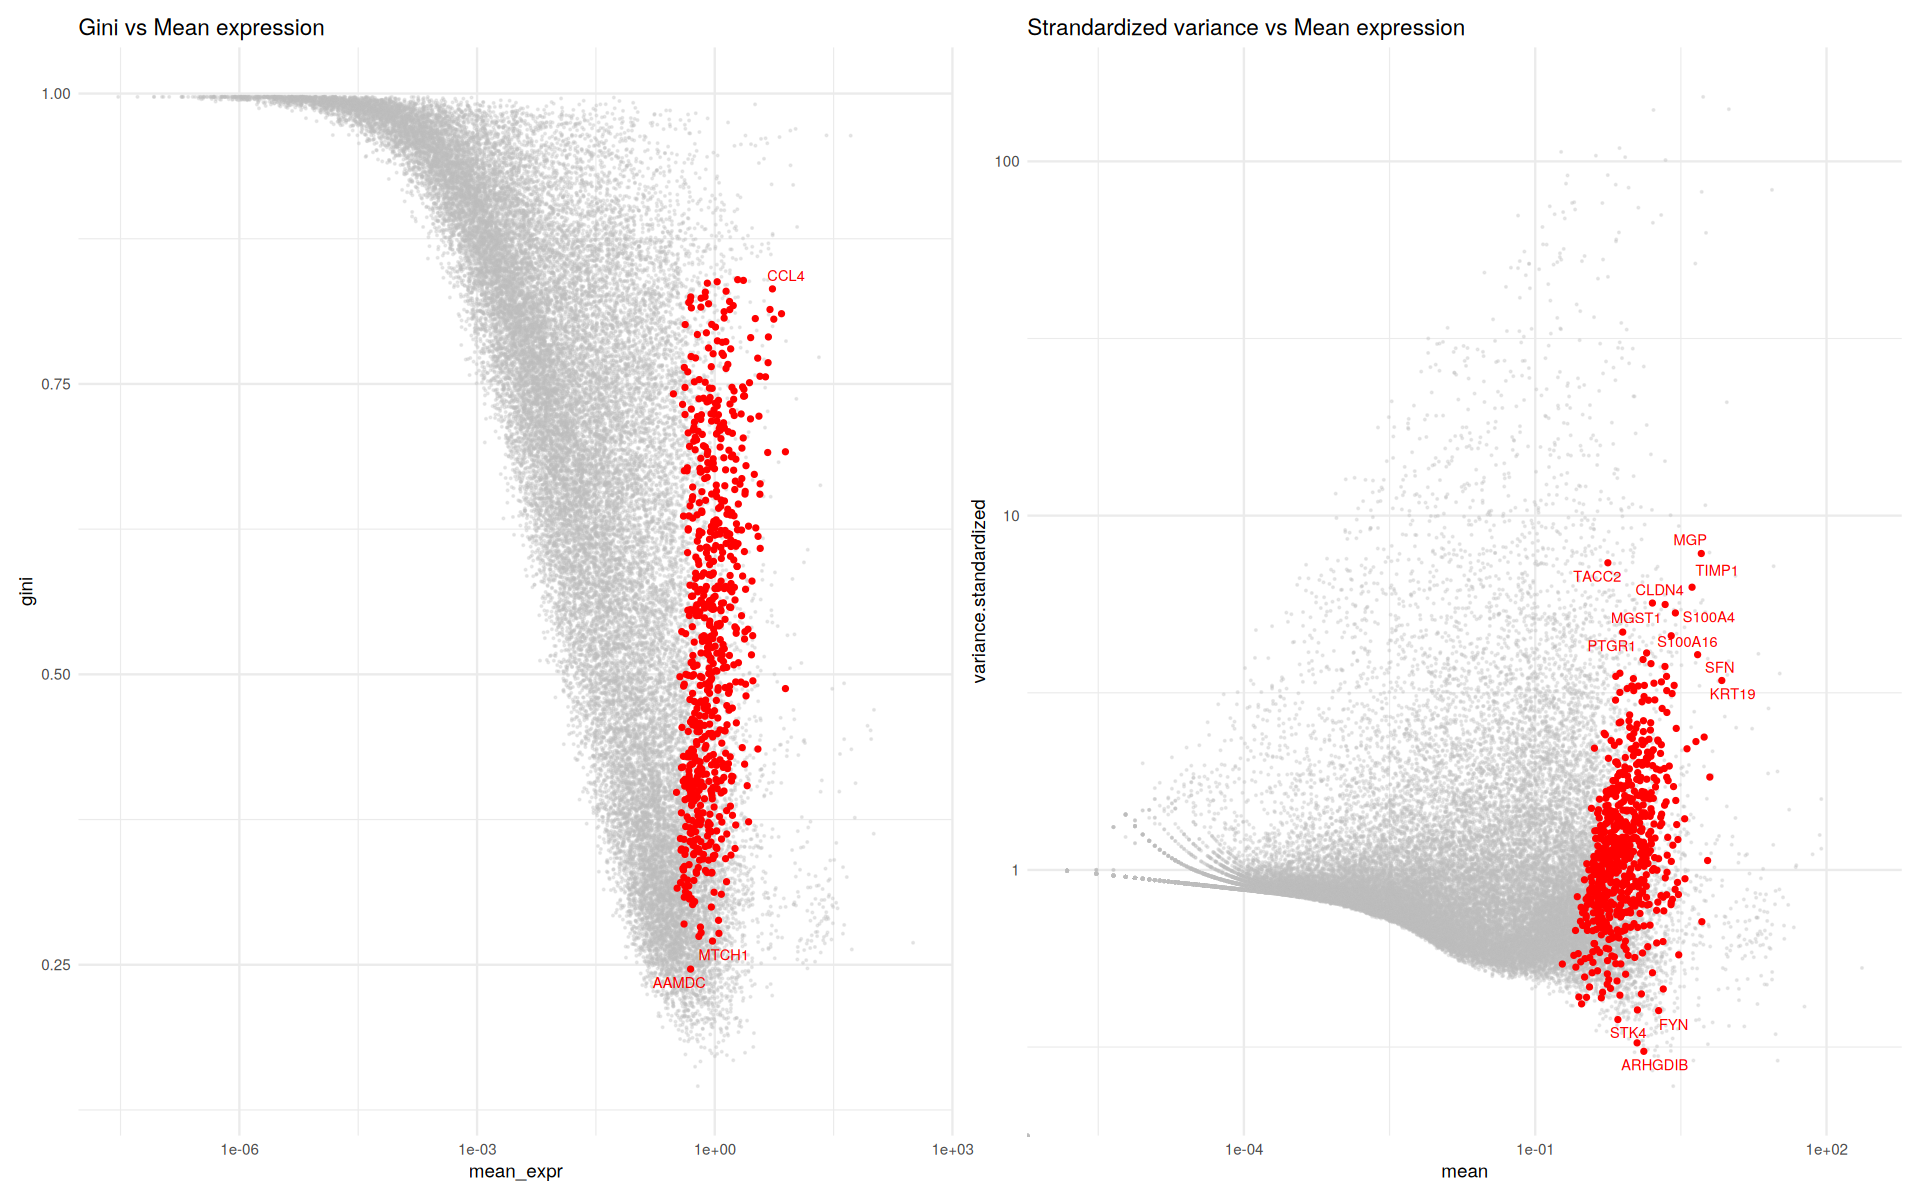

In [8]:
p1 = ggplot(uneven.genes, aes(x = mean_expr, y = gini)) +
  geom_point(alpha = 0.3, size = .1, color="grey") + 
  geom_point(data = uneven.genes %>% filter(gene %in% genes.show), color = "red", size = 1) + 
  ggrepel::geom_text_repel(data = uneven.genes %>% filter(gene %in% genes.show), aes(label = gene), color = "red", size=3) + 
  ggtitle("Gini vs Mean expression") +
  scale_x_log10() + 
  theme_minimal()

seu = FindVariableFeatures(seu, selection.method = "vst", nfeatures = 2000)
hvg = HVFInfo(seu)
hvg$gene = rownames(hvg)
p2 = ggplot(hvg, aes(x = mean, y = variance.standardized)) +
  geom_point(alpha = 0.3, size = .1, color="grey") + 
  geom_point(data = hvg[genes.show, ], color = "red", size = 1) + 
  ggrepel::geom_text_repel(data = hvg[genes.show, ], aes(label = gene), color = "red", size = 3) + 
  ggtitle("Strandardized variance vs Mean expression") +
  scale_x_log10() + 
  scale_y_log10() + 
  theme_minimal()

options(repr.plot.width = 16, repr.plot.height = 10)
p1 + p2

In [7]:
## Identify the cluster uneven genes
## 矫正mean_expr
uneven.genes = uneven.genes %>%
  mutate(log_mean = log10(mean_expr + 1e-8))  # 避免 log(0)

uneven.genes = uneven.genes %>% filter(!is.na(gini))

In [8]:
# 拟合数据：Hill方程
df <- uneven.genes %>% filter(mean_expr > 1e-6)

fit <- nls(
  gini ~ a / (1 + (mean_expr / b)^c) + d,
  data = df,
  start = list(a = 0.7, b = 0.01, c = 1, d = 0.2),
  control = list(maxiter = 500, warnOnly = TRUE)
)

In [9]:
uneven.genes$gini_fitted <- predict(fit, newdata = uneven.genes)
uneven.genes$gini_residual <- uneven.genes$gini - uneven.genes$gini_fitted
uneven.genes$gini_zscore <- scale(uneven.genes$gini_residual) %>% as.numeric()
genes.show = c("PTPRC", "CD3E", "CCL5", "GNLY", "GZMB")

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


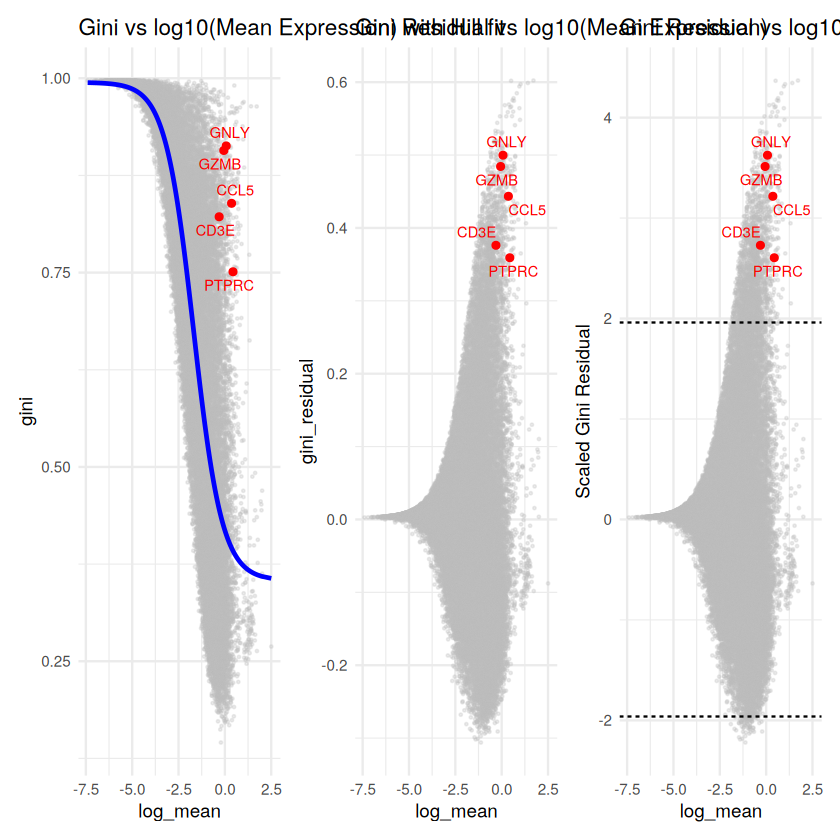

In [10]:
p1 = ggplot(uneven.genes, aes(x = log_mean, y = gini)) +
  geom_point(size = 0.3, alpha = 0.3, color = "grey") +
  geom_point(data = uneven.genes %>% filter(gene %in% genes.show), color = "red") + 
  ggrepel::geom_text_repel(data = uneven.genes %>% filter(gene %in% genes.show), aes(label = gene), color = "red", size=3) + 
  geom_line(aes(y = gini_fitted), color = "blue", size = 1) +
  ggtitle("Gini vs log10(Mean Expression) with Hill fit") +
  theme_minimal()

p2 = ggplot(uneven.genes, aes(x = log_mean, y = gini_residual)) +
  geom_point(size = 0.3, alpha = 0.3, color = "grey") +
  geom_point(data = uneven.genes %>% filter(gene %in% genes.show), color = "red") + 
  ggrepel::geom_text_repel(data = uneven.genes %>% filter(gene %in% genes.show), aes(label = gene), color = "red", size=3) + 
  ggtitle("Gini Residual vs log10(Mean Expression)") +
  theme_minimal()

p3 = ggplot(uneven.genes, aes(x = log_mean, y = gini_zscore)) +
  geom_point(size = 0.3, alpha = 0.3, color = "grey") +
  geom_point(data = uneven.genes %>% filter(gene %in% genes.show), color = "red") + 
  ggrepel::geom_text_repel(data = uneven.genes %>% filter(gene %in% genes.show), aes(label = gene), color = "red", size=3) + 
  geom_hline(yintercept = c(-1.96,1.96), linetype="dashed") + 
  ggtitle("Gini Residual vs log10(Mean Expression)") +
  ylab("Scaled Gini Residual") + 
  theme_minimal()

p1 + p2 + p3

In [11]:
uneven.genes = uneven.genes %>% arrange(desc(gini_zscore))
uneven.genes$selected = uneven.genes$gini_zscore > 1.96 # p<0.05
table(uneven.genes$selected)
genes.use = uneven.genes %>% filter(selected) %>% pull(gene)


FALSE  TRUE 
34037  1854 

In [12]:
## binary expression
## 1). Average expression
## 2). Percentage of expressed cells

expr.cutoff = 0
Idents(seu) = "iter_clusters.r1"

## 获取表达矩阵（稀疏矩阵）
expr.mat <- GetAssayData(seu, assay = "RNA",slot = "data")[genes.use, ]
## 获取 cluster 信息
clusters <- Idents(seu)

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


In [13]:
# 将 cluster 转换为因子并排序，确保列顺序一致
cluster.factor <- factor(clusters)
cluster.levels <- levels(cluster.factor)

# 初始化输出矩阵
pct.expr.mat <- matrix(NA, nrow = length(genes.use), ncol = length(cluster.levels))
rownames(pct.expr.mat) <- genes.use
colnames(pct.expr.mat) <- cluster.levels

# 二值化表达矩阵
binary.expr <- expr.mat > expr.cutoff  # sparse matrix logical

In [14]:
# 遍历每个 cluster，计算每个基因在该 cluster 中的表达比例
for (cl in cluster.levels) {
  cells.in.cluster <- which(cluster.factor == cl)
  if (length(cells.in.cluster) == 0) next
  pct.expr.mat[, cl] <- rowMeans(binary.expr[, cells.in.cluster])
}

In [15]:
## 根据otsu找到表达与否的阈值
# 直方图实现的 Otsu（作用在 0-1 数据上，返回 0-1 阈值或 NA）
otsu_hist <- function(x, nbins = 256) {
  x <- x[is.finite(x) & !is.na(x)]
  if (length(x) < 3 || length(unique(x)) <= 1) return(NA)
  h <- hist(x, breaks = nbins, plot = FALSE)
  counts <- h$counts; mids <- h$mids
  total <- sum(counts); if (total == 0) return(NA)
  sum1 <- sum(mids * counts)
  sumB <- 0; wB <- 0; maximum <- -Inf; thr <- NA
  for (i in seq_along(counts)) {
    wB <- wB + counts[i]; if (wB == 0) next
    wF <- total - wB; if (wF == 0) break
    sumB <- sumB + mids[i] * counts[i]
    mB <- sumB / wB
    mF <- (sum1 - sumB) / wF
    between <- wB * wF * (mB - mF)^2
    if (between > maximum) { maximum <- between; thr <- mids[i] }
  }
  thr
}

In [16]:
# 主函数：返回 0-1 的阈值或 NA
auto_binarize_gene_flex <- function(x, min.otsu = NULL, verbose = FALSE) {
  x <- as.numeric(x)
  x <- x[is.finite(x) & !is.na(x)]
  if (length(x) < 3) return(NA)
  if (length(unique(x)) <= 1) return(NA)
  if (all(x == 0)) return(NA)
  
  scale_factor <- 255L
  x_scaled <- as.integer(round(x * scale_factor))
  # 若量化后没有足够灰度级直接用直方图 fallback
  if (length(unique(x_scaled)) <= 1) {
    thr_frac <- otsu_hist(x, nbins = 256)
  } else {
    thr_frac <- tryCatch({
      thr_raw <- autothresholdr::otsu(x_scaled)
      if (is.na(thr_raw)) NA else thr_raw / scale_factor
    }, error = function(e) {
      if (verbose) message("autothresholdr::otsu error: ", conditionMessage(e))
      NA
    })
    if (is.na(thr_frac)) thr_frac <- otsu_hist(x, nbins = 256)
  }
  
  if (!is.null(min.otsu) && !is.na(thr_frac) && thr_frac < min.otsu) {
    if (verbose) message("threshold ", signif(thr_frac,3), " < min.otsu ", min.otsu)
    return(NA)
  }
  thr_frac
}

thresholds <- pbapply::pbapply(pct.expr.mat, 1, auto_binarize_gene_flex)

In [17]:
## 表达矩阵二值化
all(rownames(pct.expr.mat) == names(thresholds))

bin.expr.mat = sapply(1:nrow(pct.expr.mat), function(i) {
  ifelse(pct.expr.mat[i, ] > thresholds[i], 1, 0)
}) %>% t()
dim(bin.expr.mat)
rownames(bin.expr.mat) = rownames(pct.expr.mat)

features = rowSums(bin.expr.mat) > 0
table(features)

bin.expr.mat = bin.expr.mat[features, ]

[1] TRUE

[1] 1854  348

features
TRUE 
1854 

In [20]:
## 计算OT矩阵进行聚类
library(transport)
OT_dist <- function(seu, ident_column, reduction, p = 1) {
  # 设置当前鉴定标签
  Idents(seu) = ident_column
  
  # 获取cluster分组
  cell_by_clusters = CellsByIdentities(seu)
  
  # 获取所有cluster名称
  cluster_names = names(cell_by_clusters)
  n_clusters = length(cluster_names)
  
  # 获取嵌入坐标
  embeddings = Embeddings(seu, reduction = reduction)
  
  # 初始化距离矩阵
  dist_OT = matrix(0, nrow = n_clusters, ncol = n_clusters)
  rownames(dist_OT) = cluster_names
  colnames(dist_OT) = cluster_names
  
  # 遍历计算
  for (i in 1:(n_clusters-1)) {
    for (j in (i+1):n_clusters) {
      # 获取两个cluster的细胞
      cells.1 = cell_by_clusters[[cluster_names[i]]]
      cells.2 = cell_by_clusters[[cluster_names[j]]]
      
      # 获取嵌入坐标
      points.1 = embeddings[cells.1, ] 
      points.2 = embeddings[cells.2, ] 
      
      # 计算权重
      w1 = rep(1 / nrow(points.1), nrow(points.1))
      w2 = rep(1 / nrow(points.2), nrow(points.2))
      
      # 计算Wasserstein距离
      dist1 = wpp(coordinates = points.1, mass = w1)
      dist2 = wpp(coordinates = points.2, mass = w2)
      
      d1 = wasserstein(a = dist1, b = dist2, p = p)
      d2 = wasserstein(a = dist2, b = dist1, p = p)
      d = (d1 + d2) / 2
      
      # 存储到矩阵
      dist_OT[i, j] = d
      dist_OT[j, i] = d
    }
  }
  
  return(dist_OT)
}

In [21]:
## OT_dist 优化版：针对大型 Seurat 对象，对每个 cluster 进行细胞抽样
## 主要改进：
##   1. max.cells 控制每个 cluster 最多参与计算的细胞数，避免内存/时间爆炸
##   2. 预先提取各 cluster 的坐标和权重，消除循环内重复索引开销
##   3. 进度条 + verbose 日志，方便监控
##   4. seed 参数保证抽样可重复
OT_dist_sampled <- function(seu, ident_column, reduction, p = 1,
                             max.cells = 300, seed = 42, verbose = TRUE) {
  set.seed(seed)
  Idents(seu) <- ident_column

  cell_by_clusters <- CellsByIdentities(seu)
  cluster_names    <- names(cell_by_clusters)
  n_clusters       <- length(cluster_names)
  embeddings       <- Embeddings(seu, reduction = reduction)

  # 预计算：抽样 + 构建 wpp 对象
  if (verbose) message("Preparing cluster point clouds (max.cells = ", max.cells, ") ...")
  cluster_wpp <- lapply(cluster_names, function(cl) {
    cells <- cell_by_clusters[[cl]]
    n_ori <- length(cells)
    if (n_ori > max.cells) {
      cells <- sample(cells, size = max.cells)
      if (verbose) message("  [", cl, "] downsampled: ", n_ori, " -> ", max.cells)
    }
    pts <- embeddings[cells, , drop = FALSE]
    w   <- rep(1 / nrow(pts), nrow(pts))
    wpp(coordinates = pts, mass = w)
  })
  names(cluster_wpp) <- cluster_names

  # 初始化距离矩阵
  dist_OT <- matrix(0, nrow = n_clusters, ncol = n_clusters,
                    dimnames = list(cluster_names, cluster_names))

  n_pairs <- n_clusters * (n_clusters - 1L) / 2L
  if (verbose) {
    message("Computing OT distances for ", n_pairs, " pairs ...")
    pb <- txtProgressBar(min = 0, max = n_pairs, style = 3)
  }
  k <- 0L

  for (i in seq_len(n_clusters - 1L)) {
    for (j in seq(i + 1L, n_clusters)) {
      d_ij <- wasserstein(a = cluster_wpp[[i]], b = cluster_wpp[[j]], p = p)
      d_ji <- wasserstein(a = cluster_wpp[[j]], b = cluster_wpp[[i]], p = p)
      d    <- (d_ij + d_ji) / 2

      dist_OT[i, j] <- d
      dist_OT[j, i] <- d

      k <- k + 1L
      if (verbose) setTxtProgressBar(pb, k)
    }
  }
  if (verbose) { close(pb); message("Done.") }

  return(dist_OT)
}

In [22]:
dist_matrix = OT_dist_sampled(seu, "iter_clusters.r1", "rpca")

Preparing cluster point clouds (max.cells = 300) ...

  [0_0] downsampled: 21856 -> 300

  [0_1] downsampled: 19286 -> 300

  [0_2] downsampled: 14884 -> 300

  [0_3] downsampled: 11516 -> 300

  [0_4] downsampled: 8572 -> 300

  [1_0] downsampled: 17927 -> 300

  [1_1] downsampled: 13936 -> 300

  [1_2] downsampled: 9530 -> 300

  [1_3] downsampled: 9300 -> 300

  [1_4] downsampled: 3744 -> 300

  [1_5] downsampled: 384 -> 300

  [1_6] downsampled: 373 -> 300

  [10_0] downsampled: 7290 -> 300

  [10_1] downsampled: 6095 -> 300

  [10_2] downsampled: 5453 -> 300

  [10_3] downsampled: 2448 -> 300

  [10_4] downsampled: 1692 -> 300

  [11_0] downsampled: 3797 -> 300

  [11_1] downsampled: 3762 -> 300

  [11_2] downsampled: 3439 -> 300

  [11_3] downsampled: 2973 -> 300

  [11_4] downsampled: 2294 -> 300

  [11_5] downsampled: 1905 -> 300

  [11_6] downsampled: 679 -> 300

  [11_7] downsampled: 354 -> 300

  [12_0] downsampled: 3828 -> 300

  [12_1] downsampled: 3309 -> 300

  [12_2] do

  |======================================================================| 100%


Done.



In [3]:
seu = qs::qread("/home/data/tanglei/project/prostate_altas/output/04/QC_R1.qs")
dist_matrix = qs::qread("/home/data/tanglei/project/prostate_altas/output/04/dist_matrix.qs")
bin.expr.mat = qs::qread("/home/data/tanglei/project/prostate_altas/output/04/bin_matrix.qs")

In [4]:
## 二值化+可视化
library(circlize) 
library(ComplexHeatmap)
col_fun <- c("0" = "#E3D9D3", "1" = "#5A0B0F")  # or your original red tones

bin_lgd = Legend(
  labels = c("Not expressed", "Expressed"),
  legend_gp = gpar(fill = unname(col_fun)),
  title = "Expression",
  direction = "horizontal"
)

column_dend = hclust(as.dist(dist_matrix), method = "ward.D2")

qc_score = seu@meta.data[, c("qc_score", "iter_clusters.r1")] %>% 
  group_by(iter_clusters.r1) %>% 
  reframe(frac.of.high.qcscore = mean(qc_score))

r1 = qc_score$frac.of.high.qcscore 
names(r1) = qc_score$iter_clusters.r1

doublet = seu@meta.data[, c("scDblFinder.class", "iter_clusters.r1")] %>% 
  group_by(iter_clusters.r1) %>% 
  reframe(frac.of.doublet = mean(scDblFinder.class == "doublet"))

r2 = doublet$frac.of.doublet 
names(r2) = doublet$iter_clusters.r1

contamination = seu@meta.data[, c("decontX_contamination", "iter_clusters.r1")] %>% 
  group_by(iter_clusters.r1) %>% 
  reframe(frac.of.contamination = mean(decontX_contamination))

r3 = contamination$frac.of.contamination
names(r3) = contamination$iter_clusters.r1

qc = seu@meta.data[, c("final_state_GSE", "iter_clusters.r1")] %>% 
  group_by(iter_clusters.r1) %>% 
  reframe(frac.of.high = mean(final_state_GSE == "High"))

r4 = qc$frac.of.high 
names(r4) = qc$iter_clusters.r1

cols = c(
  "FALSE" = "grey",
  "TRUE" = "#2CA02C"
)

col_seq = colorRamp2(
  c(0, 1),  
  c("grey", "#2CA02C") 
)

## 注意范围
col_qc_score=colorRamp2(
  c(min(range(r1)), max(range(r1))),  
  c("grey", "#2CA02C") 
)

col_contamination=colorRamp2(
  c(min(range(r3)), max(range(r3))),  
  c("grey", "#2CA02C") 
)

col_anno = HeatmapAnnotation(
  df = data.frame(
    QC.score=as.numeric(as.character(qc_score$frac.of.high.qcscore)),
    Doublet = as.numeric(as.character(doublet$frac.of.doublet)),
    Contamination=as.numeric(as.character(contamination$frac.of.contamination)),
    QC.High = as.numeric(as.character(qc$frac.of.high))
  ),
  col = list(
    "QC.score"=col_qc_score,
    "Doublet" = col_seq,
    "Contamination"=col_contamination,
    "QC.High" = col_seq
  ),
  show_annotation_name = TRUE, show_legend = T
)

circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps in

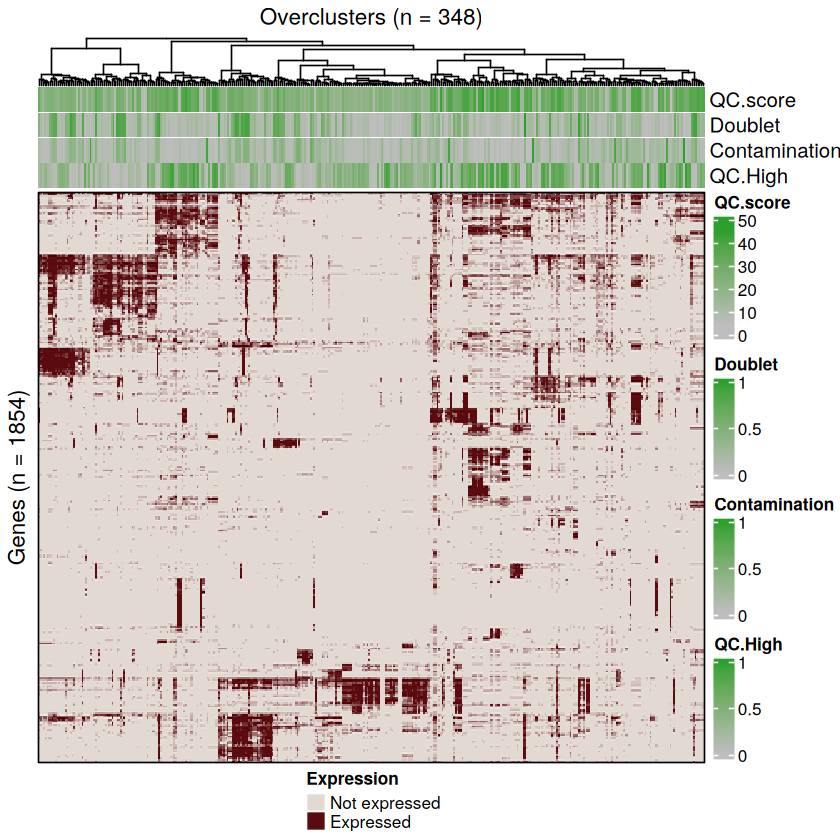

In [5]:
grid.newpage()
ht = Heatmap(
  bin.expr.mat, 
  col = col_fun,
  row_title = glue("Genes (n = {nrow(bin.expr.mat)})"),
  column_title = glue("Overclusters (n = {ncol(bin.expr.mat)})"),
  show_row_names = FALSE,
  show_row_dend = FALSE,
  cluster_columns = column_dend,
  # column_split = nrow(dist_matrix),  
  border = TRUE,
  top_annotation = col_anno, 
  show_column_names = FALSE, 
  show_heatmap_legend = FALSE,
  use_raster = TRUE  # 提高绘图效率
)

draw.ht = draw(ht, heatmap_legend_list = list(bin_lgd), heatmap_legend_side = c("bottom"))

In [6]:
## 提取聚类的群
# 每个切片内的列索引（按热图从左到右顺序）
co = column_order(ht)
slice_cols = lapply(co, function(idx) colnames(bin.expr.mat)[idx])

Warning message:
“The heatmap has not been initialized. You might have different results
if you repeatedly execute this function, e.g. when row_km/column_km was
set. It is more suggested to do as `ht = draw(ht); column_order(ht)`.”


[1] "4_2"

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



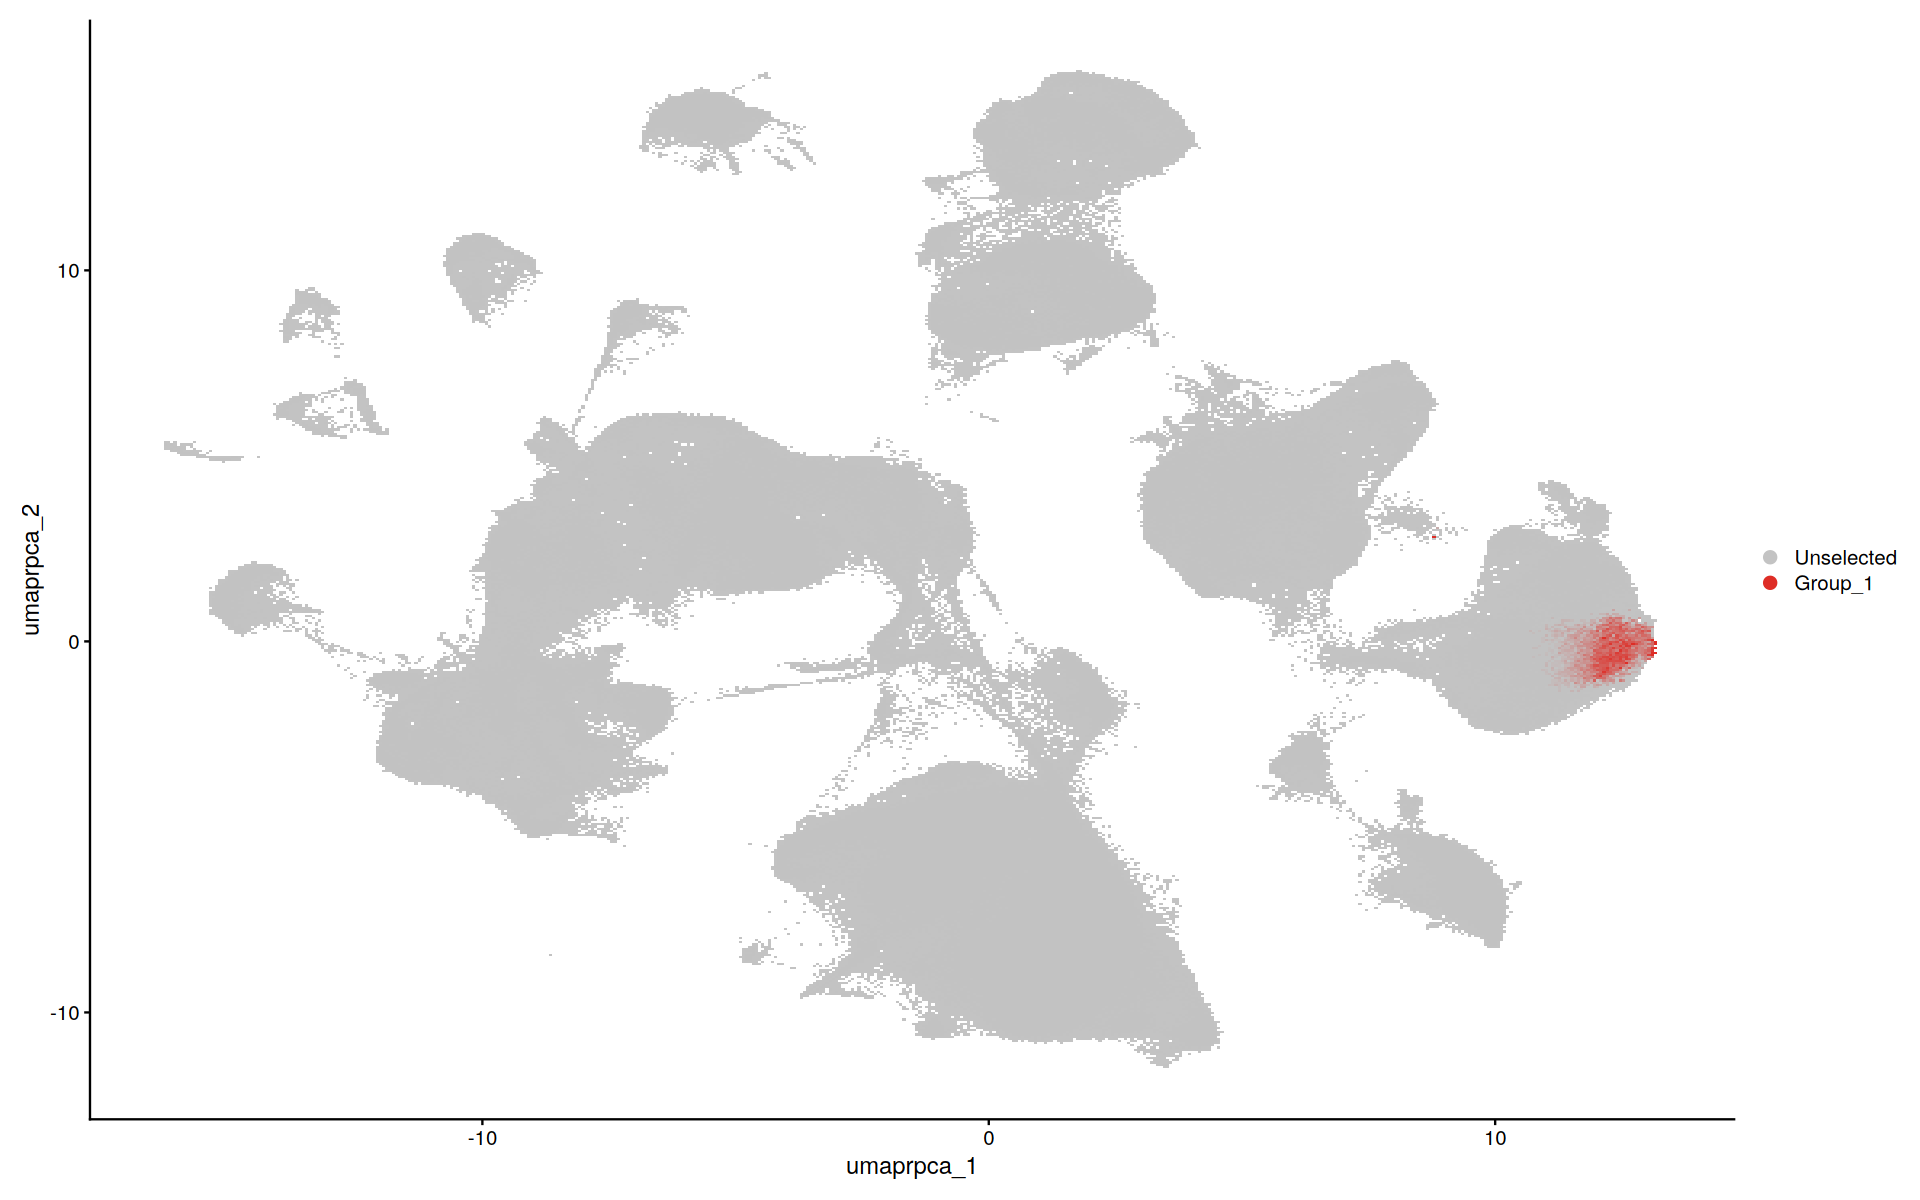

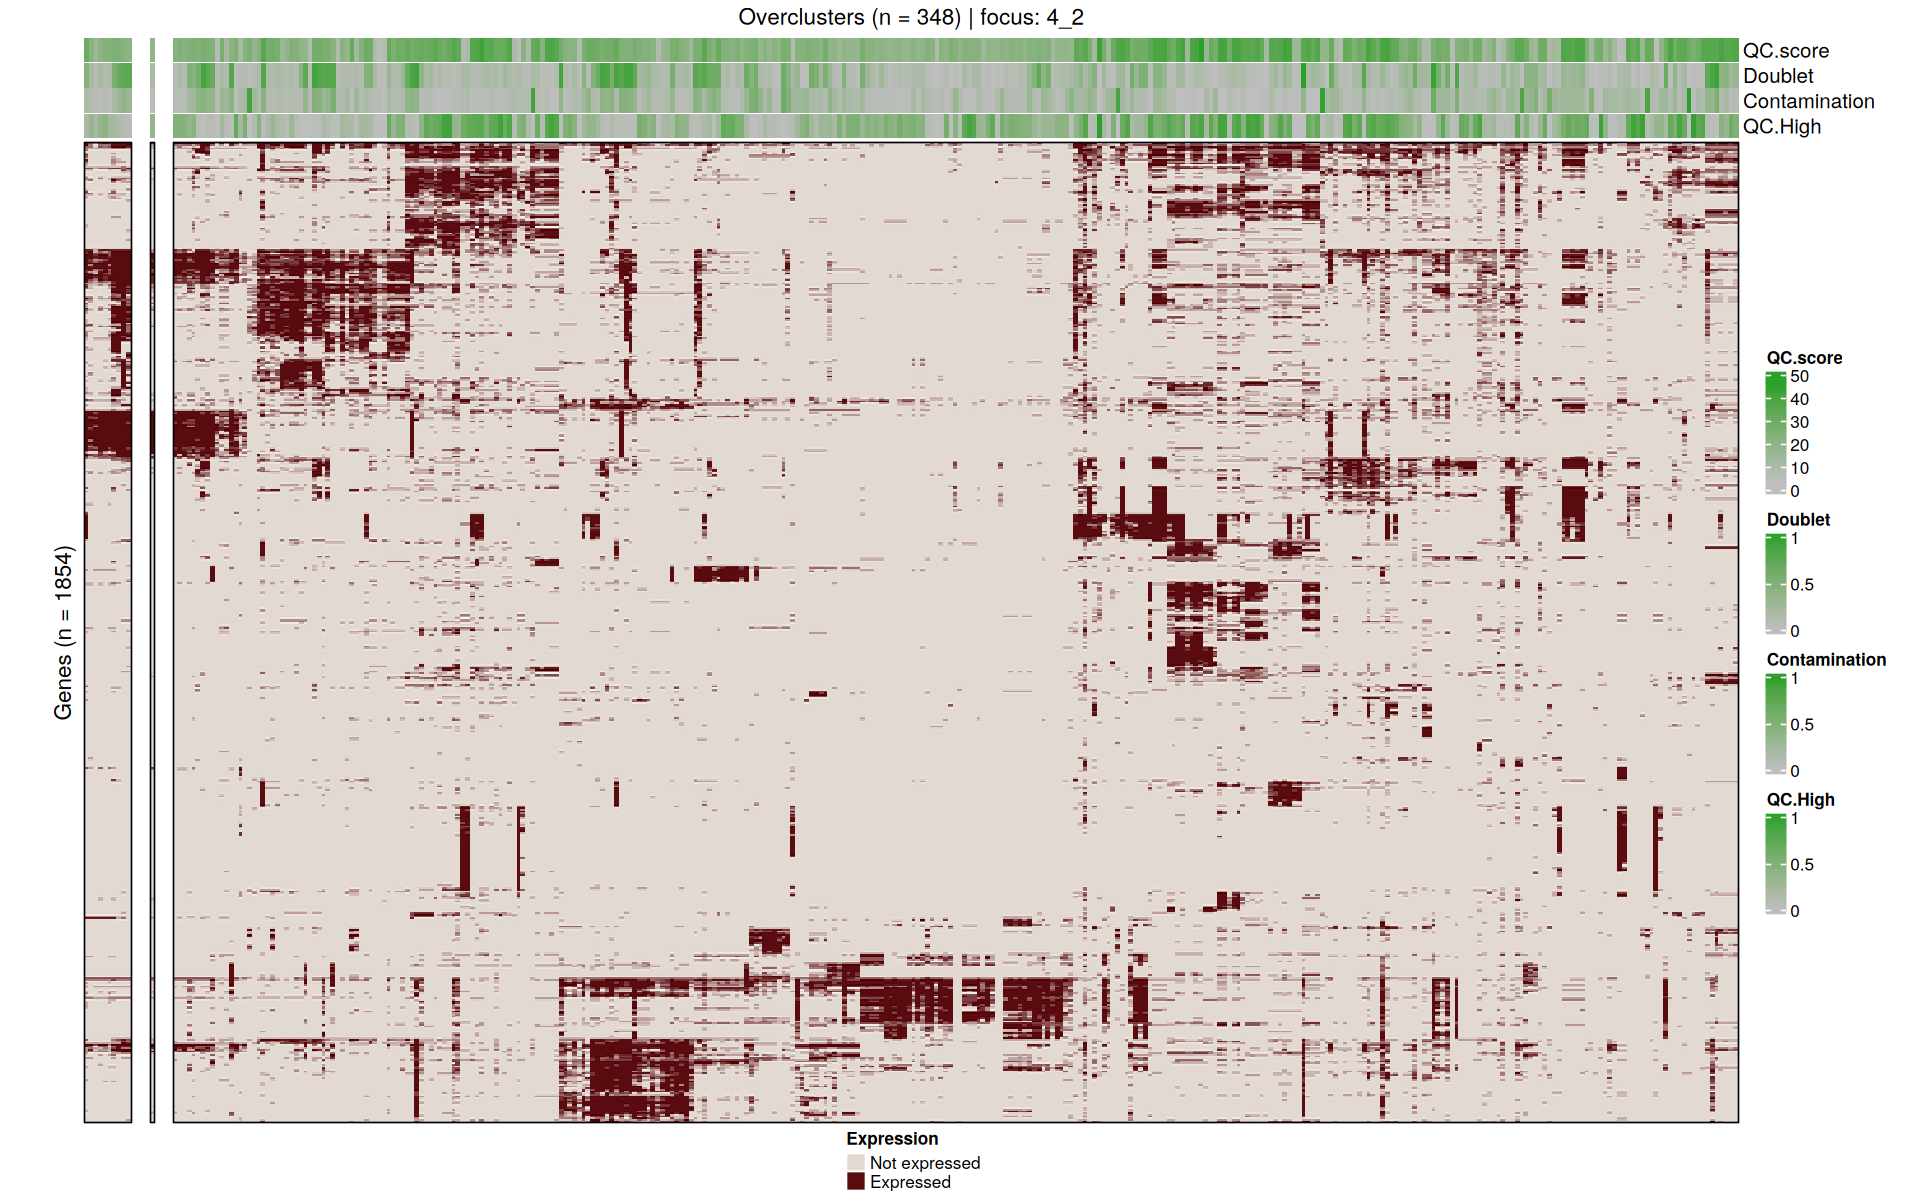

In [ ]:
## check每个群 —— 修改 idx 即可切换
idx <- 12
cluster <- slice_cols[[idx]]
cluster
DimPlot(seu, reduction = "umap.rpca",
        cells.highlight = colnames(subset(seu, subset = iter_clusters.r1 %in% cluster)))

## 热图：在原位切开高亮当前 cluster
flat_order      <- if (is.list(co)) unlist(co) else co
flat_order_name <- colnames(bin.expr.mat)[flat_order]
focus_pos       <- which(flat_order_name %in% cluster)
if (length(focus_pos) == 0) stop("No target clusters found in current heatmap column order.")

split_vec <- character(length(flat_order))
for (i in seq_along(flat_order)) {
  if (i < min(focus_pos))      split_vec[i] <- "Before"
  else if (i %in% focus_pos)   split_vec[i] <- "Focus"
  else                         split_vec[i] <- "After"
}
present   <- intersect(c("Before", "Focus", "After"), unique(split_vec))
col_split <- factor(split_vec, levels = present)

mat_ord <- bin.expr.mat[, flat_order, drop = FALSE]

anno_df <- data.frame(
  QC.score      = as.numeric(as.character(qc_score$frac.of.high.qcscore)),
  Doublet       = as.numeric(as.character(doublet$frac.of.doublet)),
  Contamination = as.numeric(as.character(contamination$frac.of.contamination)),
  QC.High       = as.numeric(as.character(qc$frac.of.high))
)

col_anno_ord <- HeatmapAnnotation(
  df = anno_df[flat_order, , drop = FALSE],
  col = list(
    "QC.score"      = col_qc_score,
    "Doublet"       = col_seq,
    "Contamination" = col_contamination,
    "QC.High"       = col_seq
  ),
  show_annotation_name = TRUE, show_legend = TRUE
)

grid.newpage()
ht_focus <- Heatmap(
  mat_ord,
  col = col_fun,
  row_title = glue("Genes (n = {nrow(bin.expr.mat)})"),
  column_title = glue("Overclusters (n = {ncol(bin.expr.mat)}) | focus: {paste(cluster, collapse = ', ')}"),
  show_row_names = FALSE,
  show_row_dend = FALSE,
  cluster_columns = FALSE,
  column_split = col_split,
  column_gap = unit(4, "mm"),
  border = TRUE,
  top_annotation = col_anno_ord,
  show_column_names = FALSE,
  show_heatmap_legend = FALSE,
  use_raster = TRUE,
  raster_by_magick = TRUE,
  width = unit(35, "cm")
)

options(repr.plot.width = 16, repr.plot.height = 10)
draw(ht_focus, heatmap_legend_list = list(bin_lgd), heatmap_legend_side = c("bottom"))

In [37]:
seu$major.celltype = "0"
seu$major.celltype[seu$iter_clusters.r1 %in% cluster] = "1"
Idents(seu) = "major.celltype"
degs = FindDEGs(seu, nn.idents = c("1", "0"))

markers <- degs %>%
  filter(
    p_val_adj < 0.05,
    avg_log2FC > 0.25,
    pct.1 > 0.10
  ) %>%
  arrange(desc(avg_log2FC), desc(pct.1 - pct.2), p_val_adj)

marker <- head(rownames(markers), 100)
marker_text <- if (length(marker) > 0) {
  paste(marker, collapse = ", ")
} else {
  "无显著marker"
}

prompt <- glue::glue(
  "我现在正在做前列腺癌及正常前列腺微环境的单细胞注释。
请你仅依据经典细胞类型标志物进行判断，不要主要依赖功能状态基因、应激基因、增殖基因、炎症反应基因或代谢相关基因。
我的这些群已经做了过度聚类，理论上应当是较单一的细胞亚群，因此如果一个群中出现多个互相冲突的经典细胞类型标志物，则优先判断为低质量细胞、双细胞或污染群，而不是强行注释成单一细胞类型。

请结合前列腺组织背景进行判断。若出现看似不属于前列腺微环境的细胞类型，请优先考虑污染、双细胞或非经典功能亚群，而不是直接给出不合理注释。

请按以下固定格式输出：
1. 是否有明确细胞类型标志物：有 / 没有
2. 是否为低质量细胞：是 / 否
3. 注释依据：列出你使用的经典 marker 组合
4. 推测的细胞类型：颗粒度参考如下：
B cell, Basal cell, CD4 T cell, CD8 T cell, Ciliated cell, Club cell, Dendritic cell, Endothelial cell, Fibroblast, Hillock cell, Luminal cell, Macrophage, Mast cell, Monocyte, Natural killer cell, Neuroendocrine cell, Neurons, Smooth muscle cell, Pericyte
5. 亚型和功能状态：如果缺乏经典依据支持，则写“无明确亚型/状态”

该群的 marker 列表为：{marker_text}

再次强调：
- 优先看经典 marker 组合
- 不要只根据功能基因判断细胞类型
- 如果 marker 彼此矛盾，直接判断为低质量细胞
- 如果缺乏经典 marker，也判断为没有明确细胞类型标志物"
)

cat(prompt)

我现在正在做前列腺癌及正常前列腺微环境的单细胞注释。
请你仅依据经典细胞类型标志物进行判断，不要主要依赖功能状态基因、应激基因、增殖基因、炎症反应基因或代谢相关基因。
我的这些群已经做了过度聚类，理论上应当是较单一的细胞亚群，因此如果一个群中出现多个互相冲突的经典细胞类型标志物，则优先判断为低质量细胞、双细胞或污染群，而不是强行注释成单一细胞类型。

请结合前列腺组织背景进行判断。若出现看似不属于前列腺微环境的细胞类型，请优先考虑污染、双细胞或非经典功能亚群，而不是直接给出不合理注释。

请按以下固定格式输出：
1. 是否有明确细胞类型标志物：有 / 没有
2. 是否为低质量细胞：是 / 否
3. 注释依据：列出你使用的经典 marker 组合
4. 推测的细胞类型：颗粒度参考如下：
B cell, Basal cell, CD4 T cell, CD8 T cell, Ciliated cell, Club cell, Dendritic cell, Endothelial cell, Fibroblast, Hillock cell, Luminal cell, Macrophage, Mast cell, Monocyte, Natural killer cell, Neuroendocrine cell, Neurons, Smooth muscle cell, Pericyte
5. 亚型和功能状态：如果缺乏经典依据支持，则写“无明确亚型/状态”

该群的 marker 列表为：ENSG00000229308, TEK, MMRN1, EBF3, TACR1, ZNF521, FGD5, LINC02147, NOSTRIN, MYRIP, PTPRB, NR5A2, ABCG2, LDB2, HOXD3, RYR3, VWF, GPM6A, SLCO2A1, ANO2, SELP, LIFR, SNTG2, RUNX1T1, PREX2, ARHGEF15, PCDH17, POSTN, DIPK2B, EMCN, ROBO4, CNTNAP3B, LINC02197, CPXM2, CYYR1, NUAK1, ZNF385D, CD34, TMTC1, ENSG00000289873, PLSCR4, FAT4, DOC2B, LEPR, GNA14,

In [ ]:
low_QC = c("35_1","35_2","35_0","35_3")

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



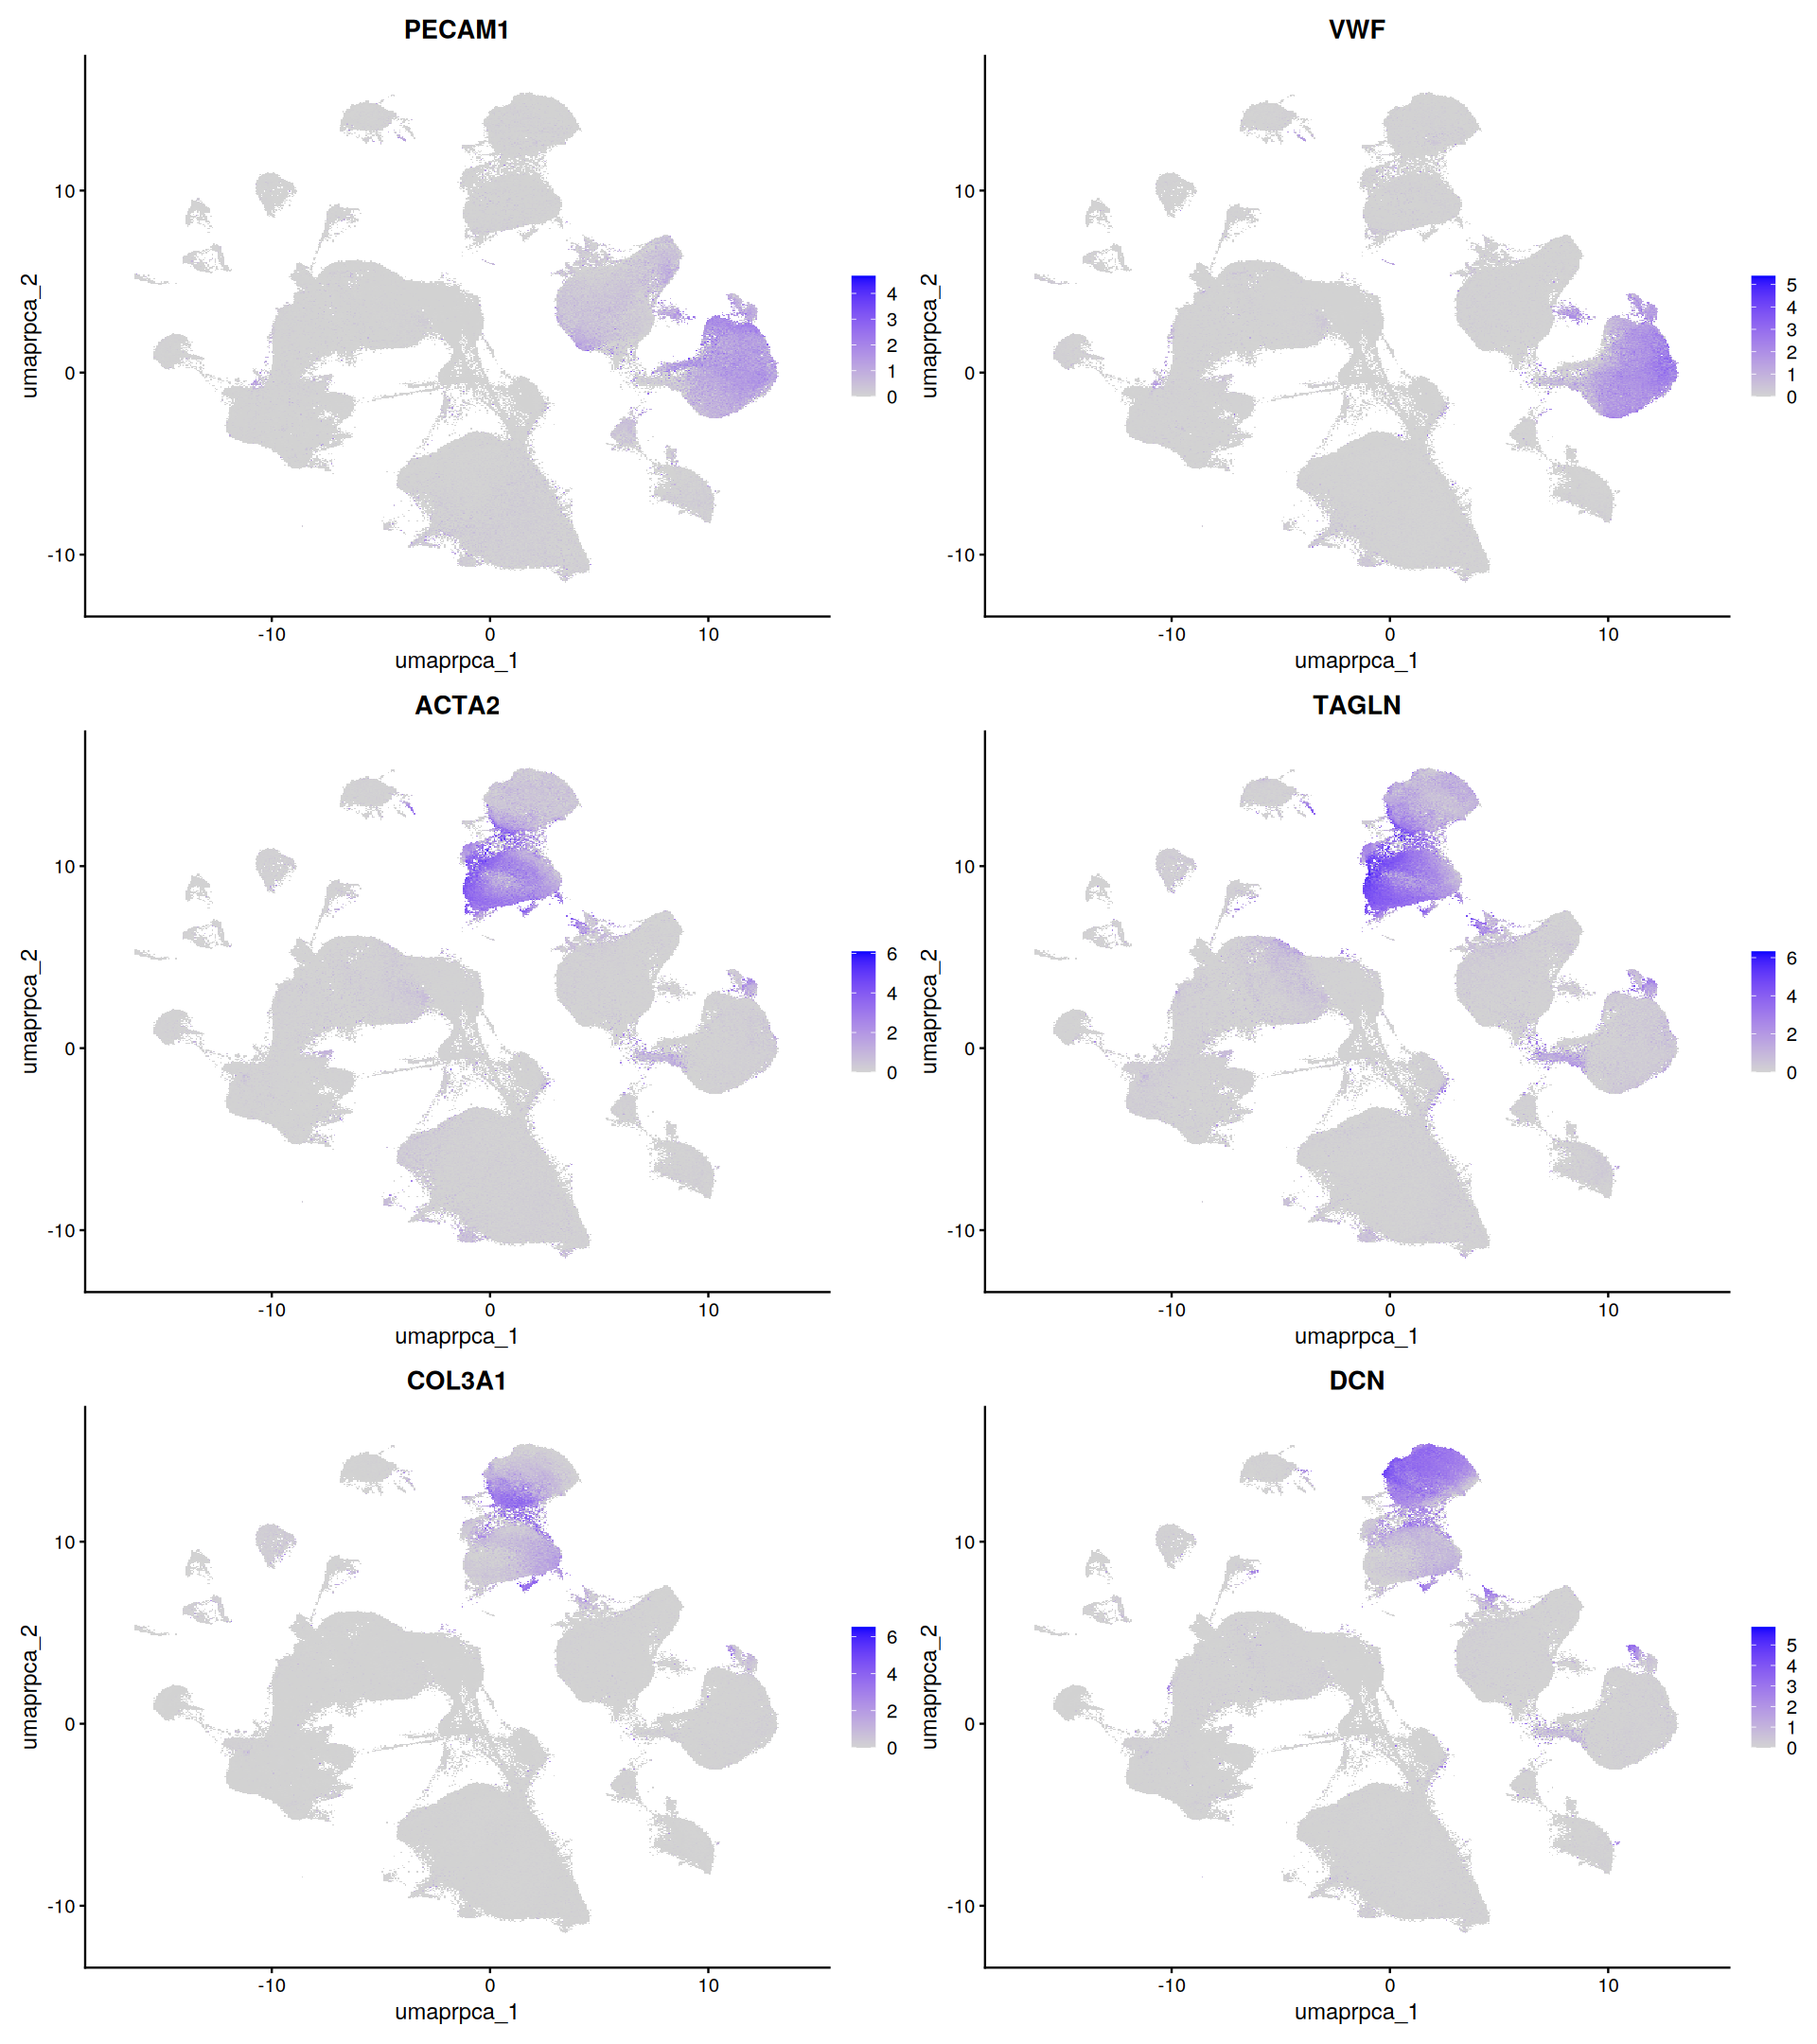

In [38]:
## 举例子，三重质控联合
options(repr.plot.width = 16, repr.plot.height = 18)
FeaturePlot(seu, features = c("PECAM1","VWF","ACTA2","TAGLN","COL3A1","DCN"),reduction = "umap.rpca")

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message in min(focus_pos):
“no non-missing arguments to min; returning Inf”
Warning message in min(focus_pos):
“no non-missing arguments to min; returning Inf”
Warning message in min(focus_pos):
“no non-missing arguments to min; returning Inf”
Warning message in min(focus_pos):
“no non-missing arguments to min; returning Inf”
Warning message in min(focus_pos):
“no non-missing arguments to min; returning Inf”
Warning message in min(focus_pos):
“no non-missing arguments to min; returning Inf”
Warning message in min(focus_pos):
“no non-missing arguments to min; returning Inf”
Warning message in min(focus_pos):
“no non-missing arguments to min; returning Inf”
Warning message in min(focus_pos):
“no non-missing arguments to min; returning Inf”
Warning message in min(focus_pos):
“no non-missing arguments to min; returning Inf”
Warning message in min(focus_pos):
“no non-missing argum

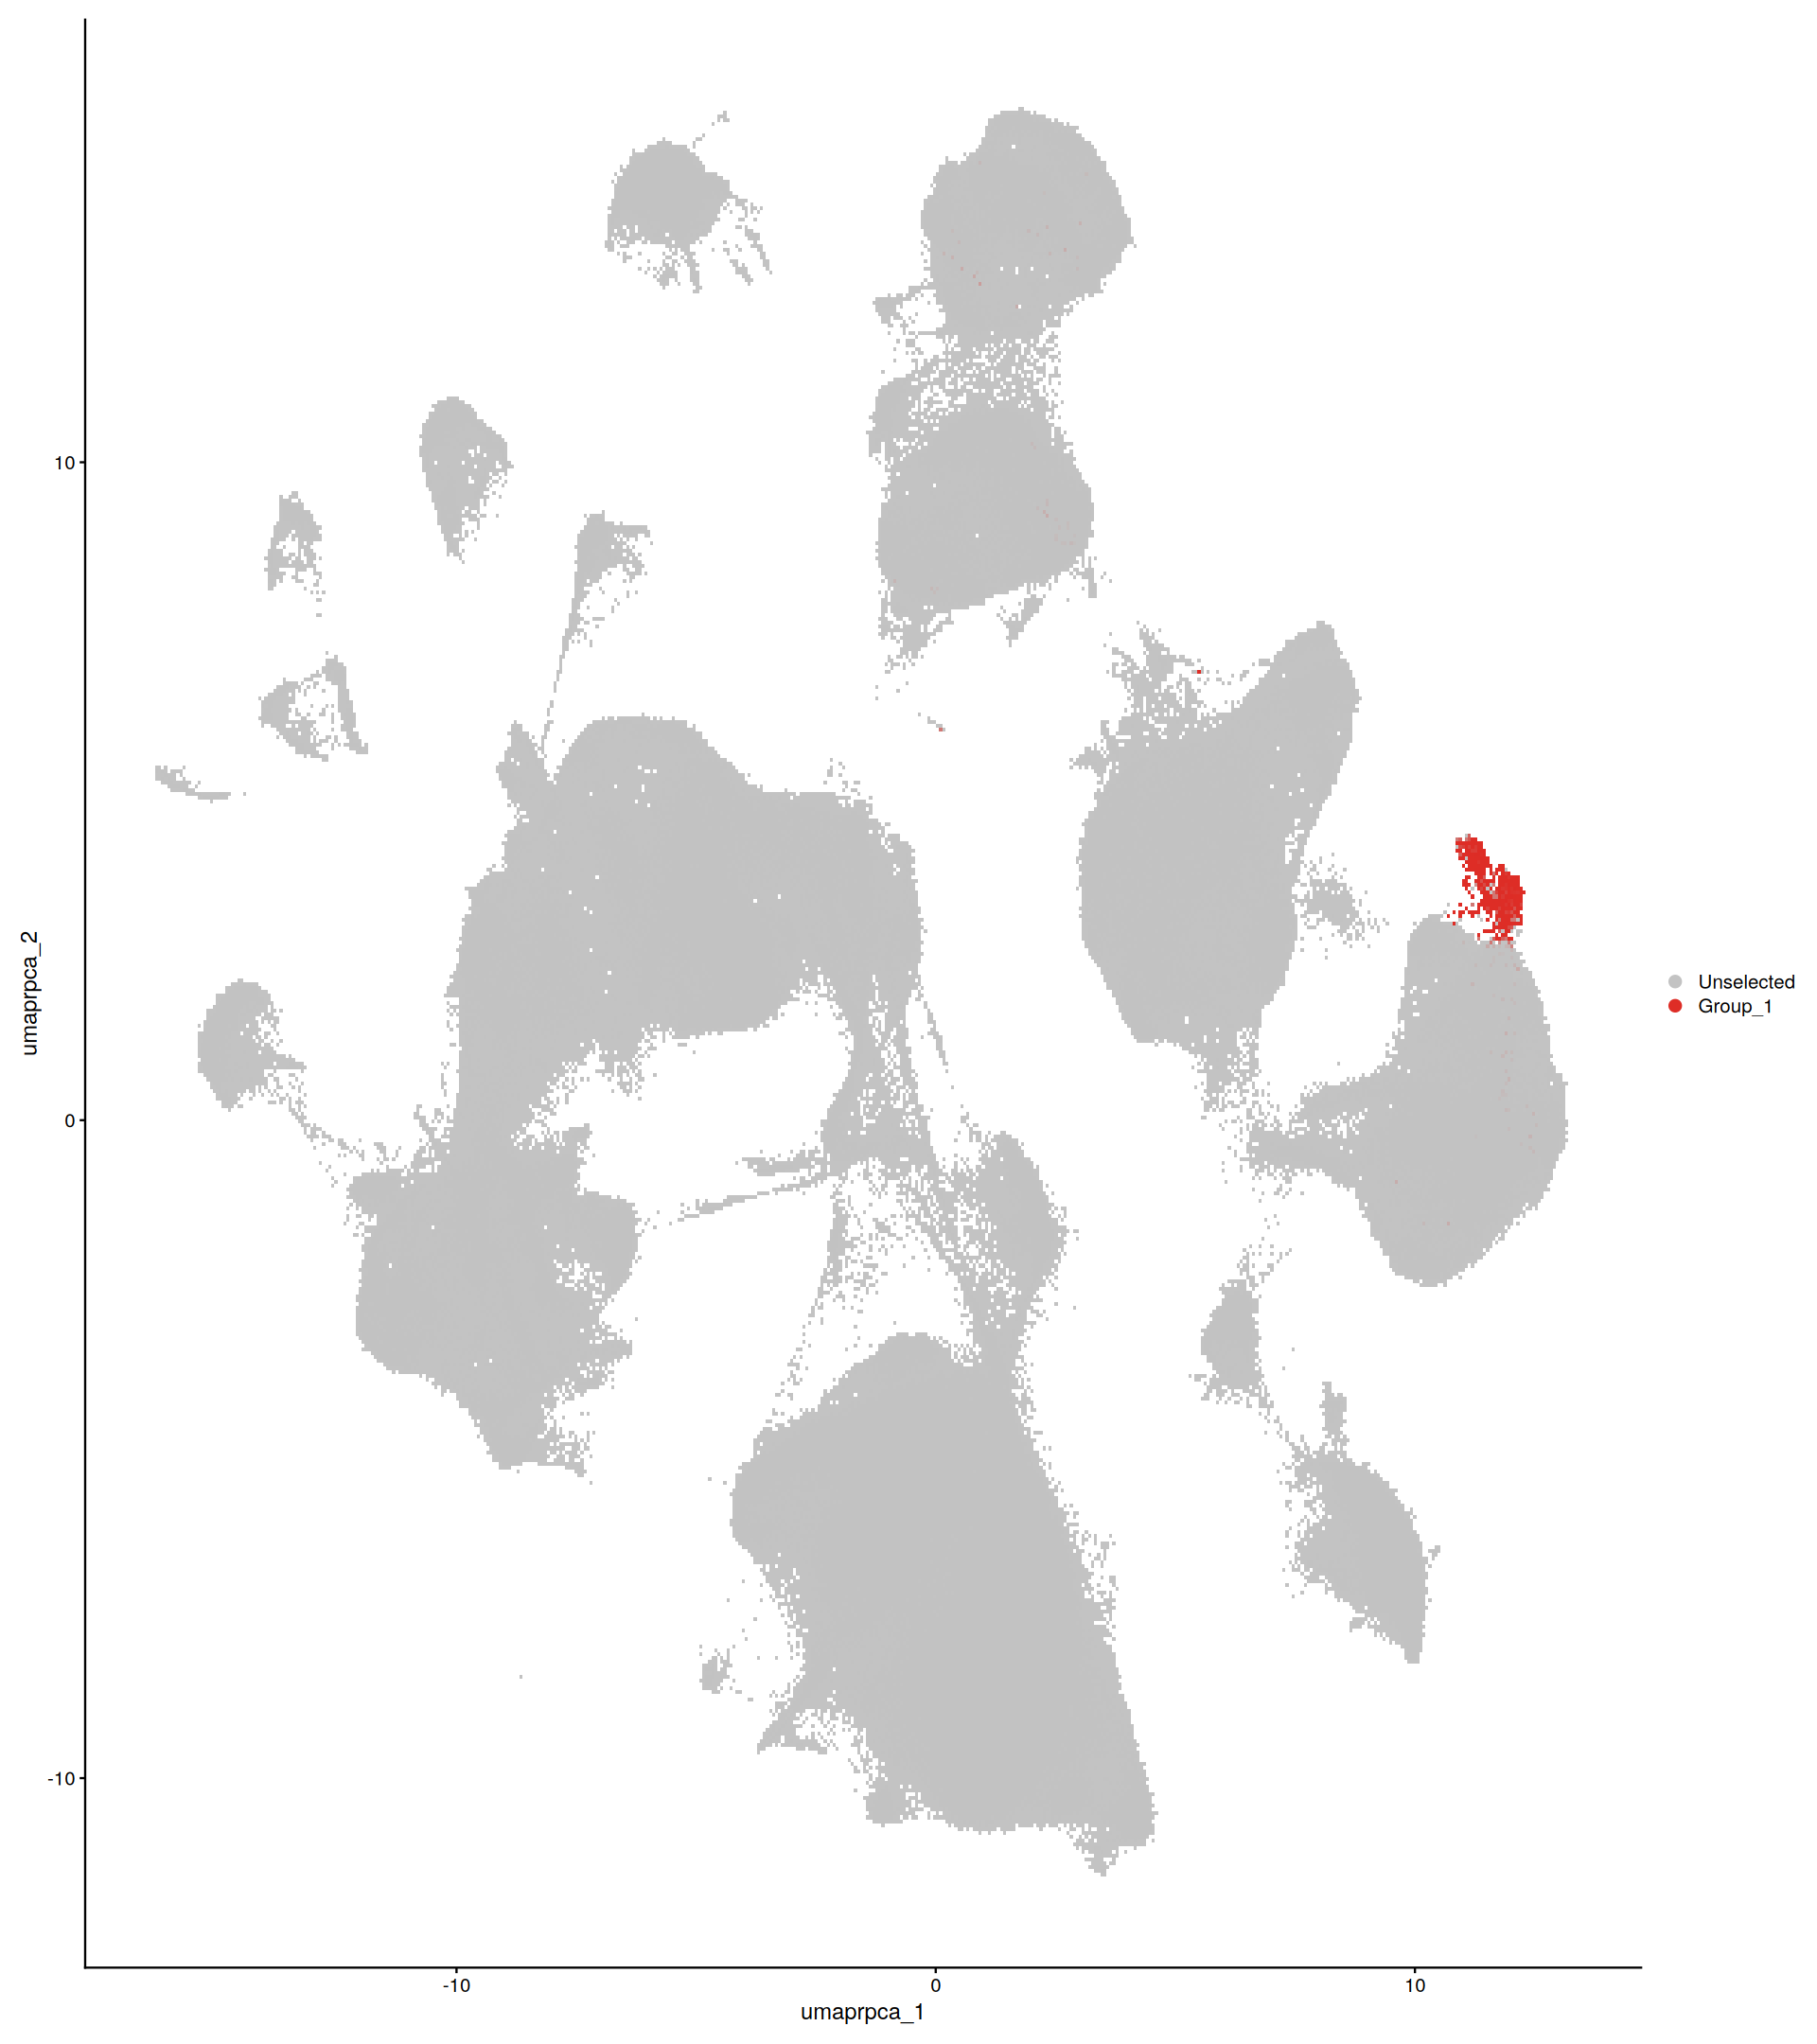

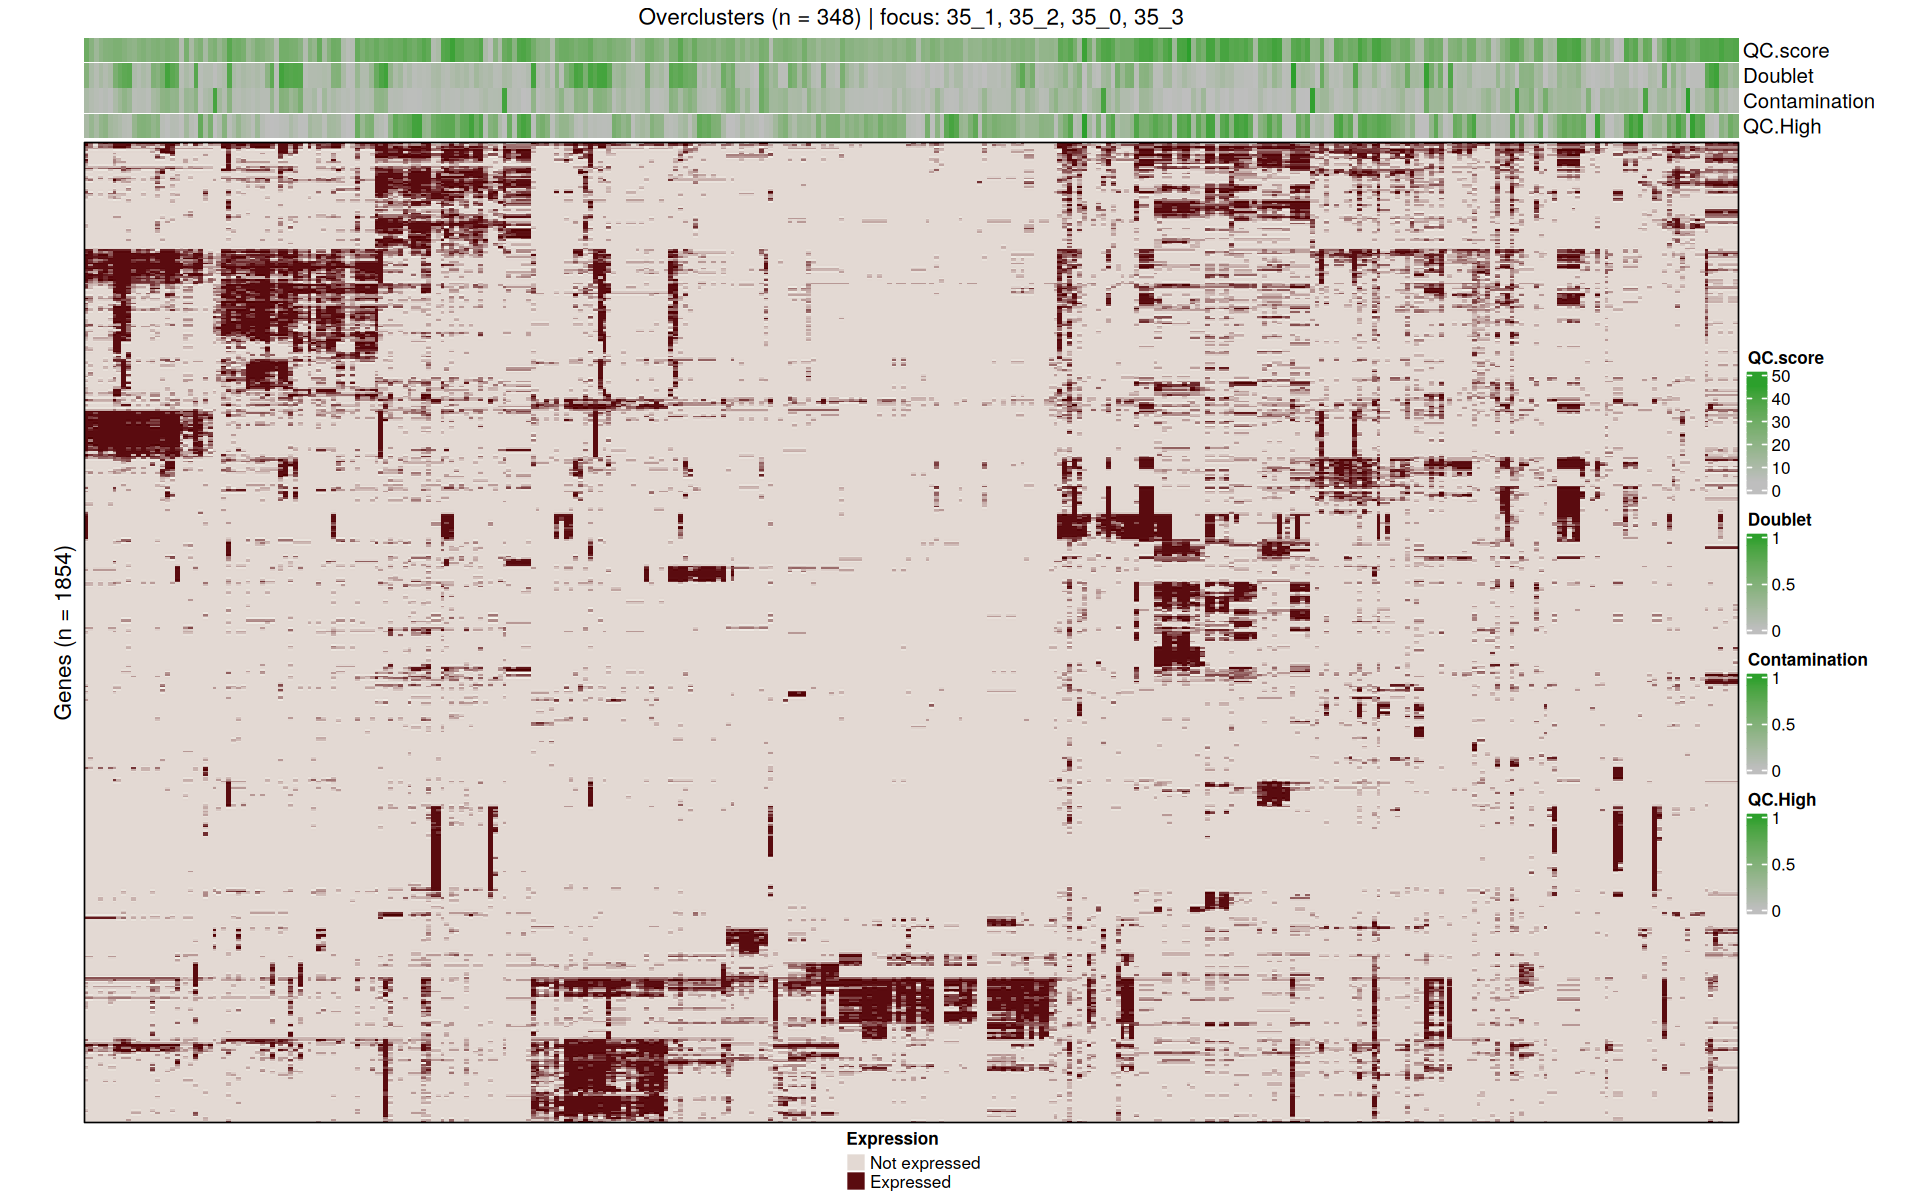

In [40]:
## check每个群 —— 手动指定 cluster
cluster <- c("35_1","35_2","35_0","35_3")
DimPlot(
  seu,
  reduction = "umap.rpca",
  cells.highlight = colnames(subset(seu, subset = iter_clusters.r1 %in% cluster))
)

## 热图：在原位切开高亮当前 cluster
flat_order      <- if (is.list(co)) unlist(co) else co
flat_order_name <- colnames(bin.expr.mat)[flat_order]
focus_pos       <- which(flat_order_name %in% cluster)
if (length(focus_pos) == 0) stop("No target clusters found in current heatmap column order.")

split_vec <- character(length(flat_order))
for (i in seq_along(flat_order)) {
  if (i < min(focus_pos))      split_vec[i] <- "Before"
  else if (i %in% focus_pos)   split_vec[i] <- "Focus"
  else                         split_vec[i] <- "After"
}
present   <- intersect(c("Before", "Focus", "After"), unique(split_vec))
col_split <- factor(split_vec, levels = present)

mat_ord <- bin.expr.mat[, flat_order, drop = FALSE]

anno_df <- data.frame(
  QC.score      = as.numeric(as.character(qc_score$frac.of.high.qcscore)),
  Doublet       = as.numeric(as.character(doublet$frac.of.doublet)),
  Contamination = as.numeric(as.character(contamination$frac.of.contamination)),
  QC.High       = as.numeric(as.character(qc$frac.of.high))
)

col_anno_ord <- HeatmapAnnotation(
  df = anno_df[flat_order, , drop = FALSE],
  col = list(
    "QC.score"      = col_qc_score,
    "Doublet"       = col_seq,
    "Contamination" = col_contamination,
    "QC.High"       = col_seq
  ),
  show_annotation_name = TRUE, show_legend = TRUE
)

grid.newpage()
ht_focus <- Heatmap(
  mat_ord,
  col = col_fun,
  row_title = glue("Genes (n = {nrow(bin.expr.mat)})"),
  column_title = glue("Overclusters (n = {ncol(bin.expr.mat)}) | focus: {paste(cluster, collapse = ', ')}"),
  show_row_names = FALSE,
  show_row_dend = FALSE,
  cluster_columns = FALSE,
  column_split = col_split,
  column_gap = unit(4, "mm"),
  border = TRUE,
  top_annotation = col_anno_ord,
  show_column_names = FALSE,
  show_heatmap_legend = FALSE,
  use_raster = TRUE,
  raster_by_magick = TRUE,
  width = unit(35, "cm")
)

options(repr.plot.width = 16, repr.plot.height = 10)
draw(ht_focus, heatmap_legend_list = list(bin_lgd), heatmap_legend_side = c("bottom"))